This file contains some plotscripts. 

To start off we run/import some code that is used both for single-angle optimizations and multi-angle optimizations.

In [1]:
import torch 
import os 

os.chdir("/Users/mmohan/Library/CloudStorage/OneDrive-TUEindhoven/Pasqal_/parametrized_gates/main_version/")

from decimal import Decimal
from schsolve import neural_trainer, schsolver 
import torchdiffeq as tdf 
import cst_n_fn as cfn 
import matplotlib.pyplot as plt 
import const_czphi as czphi 
import numpy as np 

device = "cpu"

def scale_and_offset(angle_arr, network):
    
    a = (angle_arr - network.offset)*network.scale_factor 

    return a 

/opt/homebrew/Caskroom/miniconda/base/envs/baseClone/lib/python3.11/site-packages/qutip/__init__.py:65: UserWarning: The new version of Cython, (>= 3.0.0) is not supported.
  warnings.warn(


In [6]:
filename = "data/rand_models/case_study_init_range_0.3to0.5_mid2"
filename = "data/rand_models/case_study_0.3_to_0.5_definitive"
filename = "data/rand_models/case_study_0.1_to_0.3"
filename = "data/rand_models/case_study_init"
#filename = "data/rand_models/radam_12_300"
#filename = "data/seq_small/partial_sec_7"
filename = "data/rand_models/case_study_5e-4_to_0.02pi"
filename = "data/rand_models/case_study_0.05_to_0.3"
filename = "data/rand_models/case_study_init_range_0.5to1_mid"
filename = "data/final_models/pt3pi_to_pt5pi"
#filename = "data/rand_models/case_study_0.1_to_0.5_definitive"

load_dict = torch.load(filename)#_fullangle")
composite_network = load_dict["network"].to(device)
composite_network._aux_tensor = composite_network._aux_tensor.to(device)
nn_solver_1 = load_dict["solver"][0]
nn_solver_2 = load_dict["solver"][1]

desired_angle = load_dict["angle"].to(device)


Note: the code cell right below is to to demonstrate (and potentially utilize) file handling i.e. loading a pre-trained NN. You can comment out the lines if you just want to train a randomly initialized NN. The pre-trained NN being loaded is one that generates controls for the time-optimal $CZ$ gate, it should be a decent guess for the multi-angle optimization as well. 

In [ ]:
# code to plot gatetime

angle_list = torch.linspace(0.5*torch.pi, torch.pi, czphi.angle_batch).reshape(czphi.angle_batch, 1)
angle_list = torch.linspace(0.3*torch.pi, 1*torch.pi, 101).reshape(101, 1)

composite_network(angle_list)

plt.figure(dpi = 200)
plt.scatter(angle_list.detach().numpy()/torch.pi,\
     composite_network.gatetime_prediction.detach().numpy()*cfn.rabi/7.6175, color = 'green', s = 0.4)
plt.xlabel(r"Angle $\theta/\pi$")
plt.ylabel(r"Gatetime $T/T_{\theta = \pi}$")
plt.xlim(0.0, 1.0)
plt.ylim(0.45, 1.0)
print(composite_network.gatetime_prediction[-1]*cfn.rabi)

(25728,)
(25728,)
torch.Size([25728])


Text(0.5, 0, '$\\Delta/\\Omega_{max}$')

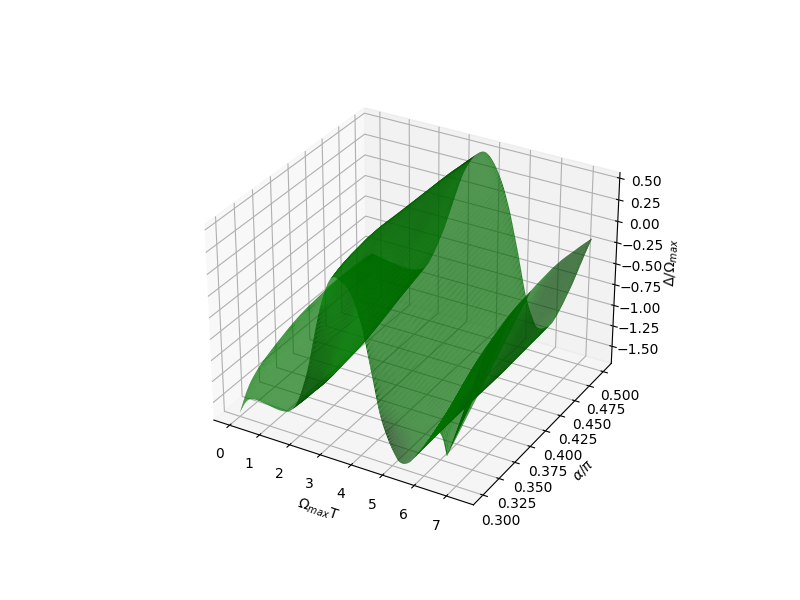

In [8]:
# code for 3d plot 
%matplotlib widget

czphi.angle_batch = 128
angle_list = torch.linspace(0.3*torch.pi, 0.5*torch.pi, czphi.angle_batch).reshape(czphi.angle_batch, 1)

composite_network(angle_list)

# Now a plot, same reasoning as last time -- the initial controls should not hover around 0
time_list = []
for i in range(czphi.angle_batch):

    time_arr = torch.linspace(0, composite_network.gatetime_prediction[i].item()\
        , czphi.time_steps).reshape((czphi.time_steps, 1)).to(device)
    time_list.append(time_arr)

x = torch.cat(time_list).ravel().cpu().detach().numpy()*cfn.rabi
print(x.shape)
# = time_arr.reshape(angle_batch*time_steps).cpu().detach().numpy()*cfn.rabi # * should work for time-optimal case but more care needs to be put in 
angle_list_cat = []

for i in range(czphi.angle_batch):
    
    angle_list_cat.append(torch.ones(201)*(angle_list[i].item()))

angle_list_cat = torch.cat(angle_list_cat)
y = angle_list_cat.detach().numpy()/torch.pi

pred_outputs_det = composite_network(angle_list).select(1,0)*\
    (czphi.range_detuning[1] - czphi.range_detuning[0]) + czphi.range_detuning[0]

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.set_xlabel(r'$\Omega_{max}$T')
ax.set_ylabel(r'$\alpha/\pi$')
    
print(y.shape)

print(pred_outputs_det.shape)
ax.plot_trisurf(x, y, pred_outputs_det.detach().numpy()/cfn.rabi, color = 'green')
ax.set_zlabel(r'$\Delta/\Omega_{max}$') 
#if save_flag[0] == True:
#        plt.savefig(save_flag[1], transparent=True)




In [ ]:
# Code to plot the pulses at different angles 

print(czphi.angle_batch)
angle_list = torch.linspace(0.5, 1*np.pi, czphi.angle_batch).reshape(czphi.angle_batch, 1)
angle_list = [torch.pi/6, torch.pi/4, torch.pi/2, torch.pi]
labels = [r'$\pi/6$', r'$\pi/4$', r'$\pi/2$', r'$\pi$']


def plot_list(angle_list, label):
    
    instances = len(angle_list)
    angle_list = torch.tensor(angle_list)
    print(angle_list.shape[0])
    angle_list = angle_list.reshape(angle_list.shape[0], 1)
    detuning = composite_network(angle_list)*(czphi.range_detuning[1] - czphi.range_detuning[0]) + czphi.range_detuning[0]
    detuning = detuning/cfn.rabi
    # ? why no scaling above? 
    time_arr = composite_network.gatetime_prediction.reshape(instances).detach().numpy()
    plt.figure(dpi = 200)

    for n in range(instances):
        
        detuning_current = detuning[n*101:(n+1)*101].detach().numpy()
        time_arr_current = np.linspace(0, time_arr[n], 101)
        plt.plot(time_arr_current/(7.6175/cfn.rabi), detuning_current, label = label[n])
    plt.xlim(0.0, 1.0)
    #plt.ylim(0.65, 2.0)
    
    plt.legend()
    plt.ylabel(r"Detuning $\Delta/\Omega_{\mathrm{max}}$")
    plt.xlabel(r"Gatetime $T/T_{\theta = \pi}$")
    plt.show()


plot_list(angle_list, labels)

In [ ]:
print(czphi.angle_batch)
load_dict = torch.load("data/rand_models/var_gatetime_cz_converged_2")

# choose file 'var_gatetime_cz_converged_2' instead for the single angle optimization 
angle = (torch.ones(1)*torch.pi).reshape(1, 1)
detuning = load_dict["network"](angle)*(czphi.range_detuning[1] - czphi.range_detuning[0]) + czphi.range_detuning[0]
time_arr = np.linspace(0, load_dict["network"].gatetime_prediction.item()*cfn.rabi, 101)
plt.figure(dpi=200)
plt.xlim(0, 7.6175)
plt.ylim()

plt.xlabel(r"Gatetime $\Omega_{max}T$")
plt.ylabel(r"Detuning $\Delta/\Omega_{max}$")
plt.plot(time_arr, detuning.detach().numpy()/cfn.rabi, color = 'green')
plt.show()


In [64]:
# code to edit older dictionaries to fit with the new standard 

#filename = "data/rand_models/case_study_init_range_0.5to1_mid"

filename = "data/rand_models/case_study_0.3_to_0.5_definitive"
filename = "data/rand_models/case_study_0.1_to_0.5_definitive"
filename = "data/rand_models/case_study_init_range_0.1to0.5_mid"
filename = "data/rand_models/case_study_0.1_to_0.3"
#filename = "data/rand_models/case_study_0.1_to_0.5_definitive"
load_dict = torch.load(filename)
composite_network = load_dict["network"].to(device)

composite_network.scale = [0.0, 1.0]
composite_network.offset = 0.0
composite_network.scale_factor = 1.0 
composite_network._aux_tensor = composite_network._aux_tensor.to(device)

nn_solver_1 = load_dict["solver"][0]
nn_solver_2 = load_dict["solver"][1]

desired_angle = load_dict["angle"].to(device)

# ! Change below lines depending on the dictionary 
composite_network.angle_range = [0.1*torch.pi, 0.3*torch.pi]
composite_network.range_detuning = [-2.0*cfn.rabi, 2.0*cfn.rabi]


In [14]:
# code to only load new dictionaries 
filename = "data/rand_models/study_0.05_to_1pi"
load_dict = torch.load(filename)
composite_network = load_dict["network"].to(device)
#desired_angle = load_dict["angle"].to(device)

In [46]:
# code to plot variance in fidelity 
import schsolve
from const_czphi import reduce_r_dim_2q_vector, correction_1q 

#instance = schsolve.schsolver(czphi.system, 1, mode = "single").to(device)
instance = czphi.instance
print(czphi.angle_batch)

def run_file(filename_arr):

 plt.figure(dpi = 200)
 plt.yscale('log')
 plt.ylabel(r'Infidelity $(1 - F)$')
 plt.xlabel(r'Angle $\theta/\pi$')
 total_steps = 101
 step_sum = 0
 x_list = []
 fidelity_arr = []
 gatetime_prediction = []
 angles_to_plot = [torch.pi/8, torch.pi/6, torch.pi/4, torch.pi/2, torch.pi]
 
 for filename in filename_arr: 

  load_dict = torch.load(filename[0])
  composite_network = load_dict["network"].to(device)
  steps = round((np.abs(filename[1][1] - filename[1][0])/torch.pi)*total_steps)
  step_sum += steps
  print(steps)
  angle_list = torch.linspace(composite_network.angle_range[0], \
    composite_network.angle_range[1], steps).reshape(steps, 1)
  angle_list_scaled = scale_and_offset(angle_list, composite_network)
  for i in angle_list_scaled: 

    i = i.reshape(1,1)
    pred_outputs_detuning = (composite_network(i).\
        select(1,0))*(composite_network.range_detuning[1] - \
            composite_network.range_detuning[0]) + composite_network.range_detuning[0]
    #print(pred_outputs_detuning.shape)
    instance.hamiltonian.rabi_tensored["pulse 0"] = instance.hamiltonian.rabi_tensored["pulse 1"]\
    = cfn.const_then_zero_tensor(1*cfn.rabi, composite_network.gatetime_prediction)

    instance.hamiltonian.det_tensored["pulse 0"] = instance.hamiltonian.det_tensored["pulse 1"]\
        = czphi.list_to_fn_tensor_var_gatetime(pred_outputs_detuning, composite_network.gatetime_prediction, czphi.time_steps)
    instance.hamiltonian.decay_width = 1/(96.5*10/4)
    time_arr_ = torch.linspace(0, 1.0, 301, device = device)*composite_network.gatetime_prediction.max()
    sol_intrm = reduce_r_dim_2q_vector(tdf.odeint(instance,\
                                torch.eye(9, dtype = torch.cfloat).reshape(1,9,9), time_arr_, 
                                method = 'rk4')[-1], angle_batch = 1)
    solution = correction_1q(sol_intrm, angle_batch = 1) 
    fidelity = (cfn.unitary_infidelity_array(cfn.czp_gate_stack(i/composite_network.scale_factor + composite_network.offset), solution, nqbits = 2))
    fidelity_arr.append(fidelity.item())
    gatetime_prediction.append(composite_network.gatetime_prediction.item())
    #print(fidelity.item())
  x_list.append(angle_list.detach().numpy())

 x_list = np.concatenate(x_list)
 print(len(x_list.T[0]))
 print(len(fidelity_arr))
 plt.scatter(x_list.T[0], np.array(fidelity_arr), s = 0.3, color = 'red')
 
 plt.show()
 return (fidelity_arr, np.array(gatetime_prediction), x_list)#, pulses)

1


1
[0.22668111324310303, 0.2593402862548828, 0.2904411852359772, 0.3148752450942993]
[0.22668111324310303, 0.2593402862548828, 0.2904411852359772, 0.3148752450942993]
[0.22668111324310303, 0.2593402862548828, 0.2904411852359772, 0.3148752450942993]
[0.22668111324310303, 0.2593402862548828, 0.2904411852359772, 0.3148752450942993]


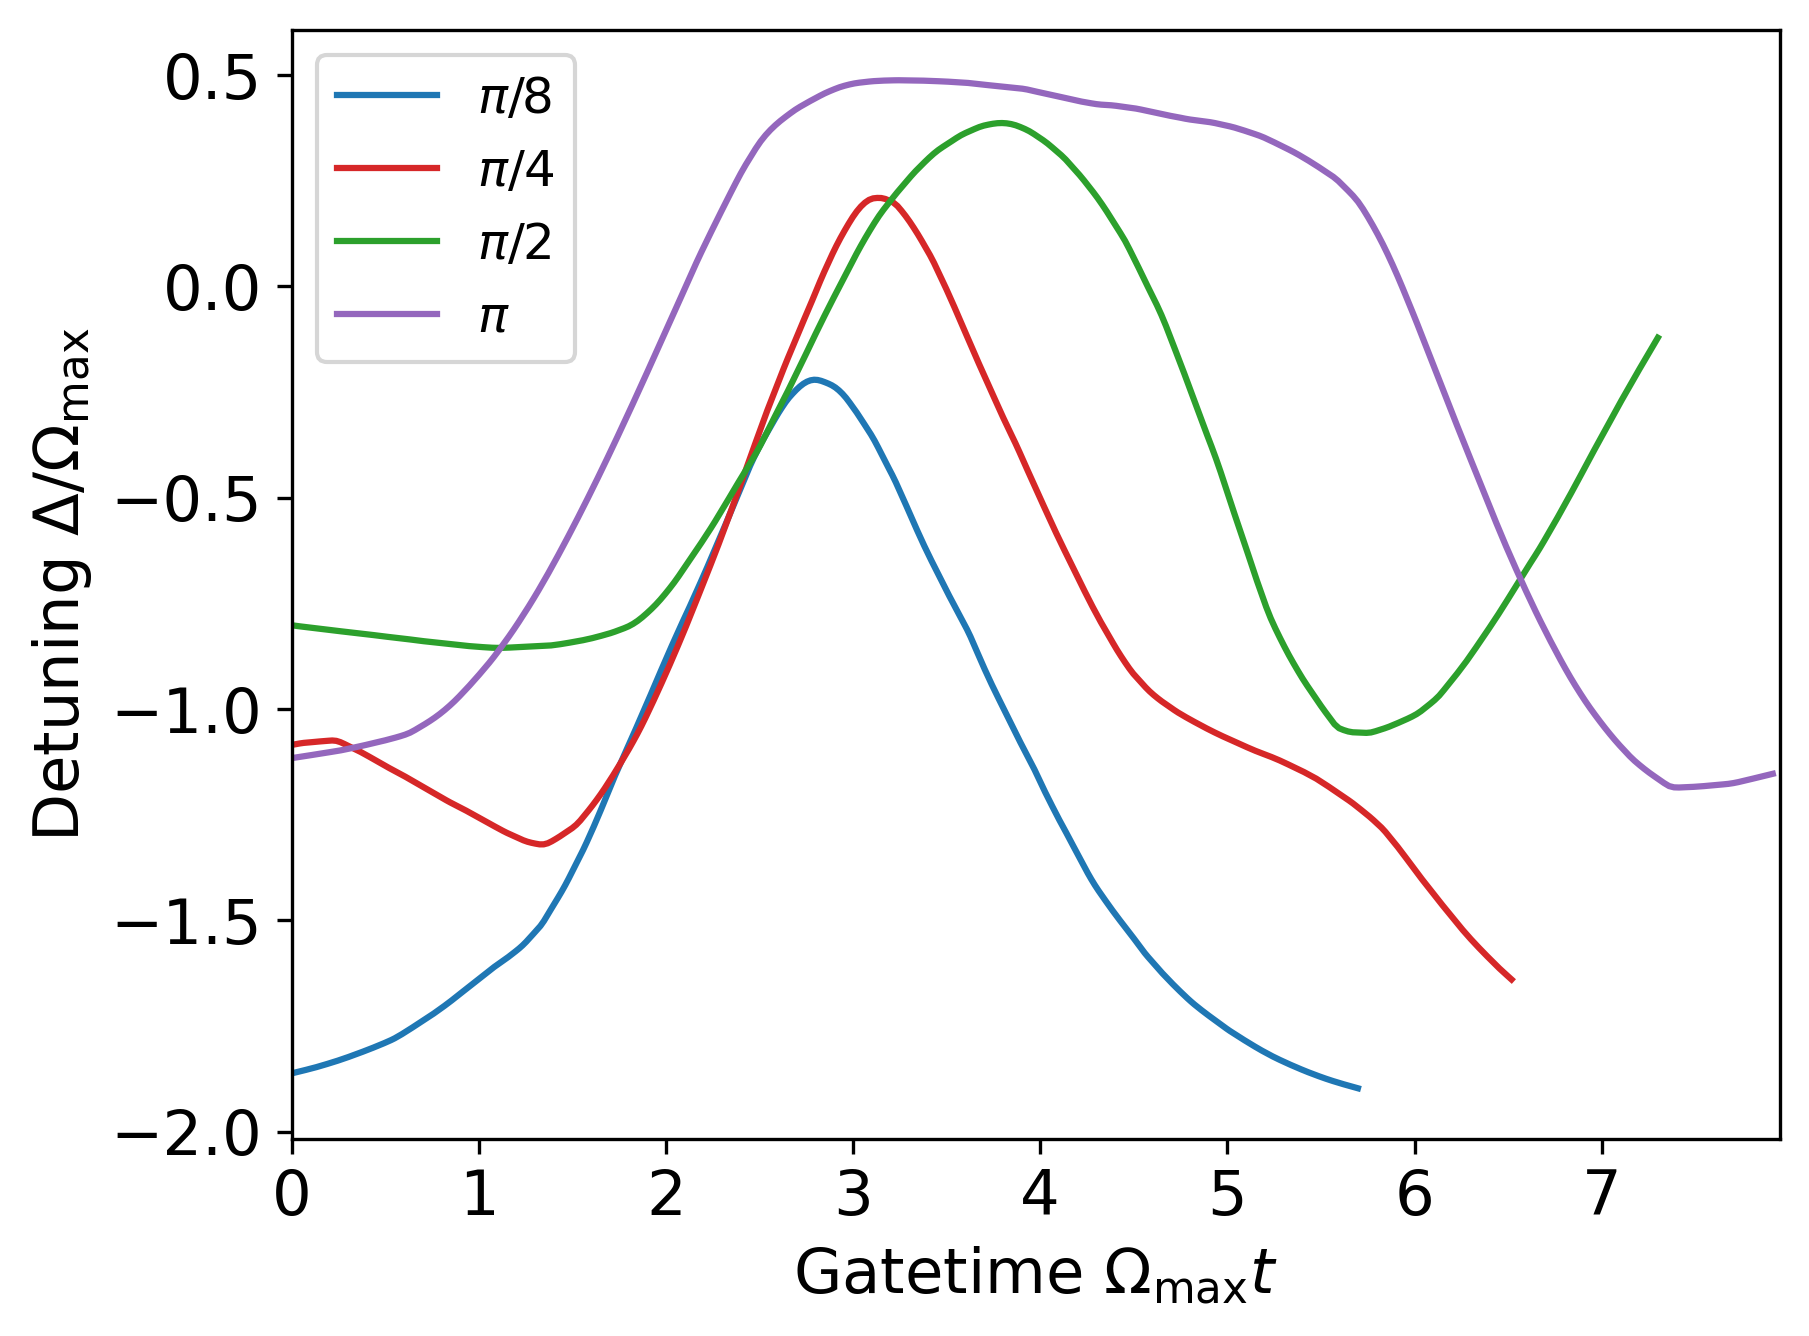

In [35]:
# code to plot variance in fidelity 
import schsolve
from const_czphi import reduce_r_dim_2q_vector, correction_1q 
from scipy.interpolate import interp1d
#instance = schsolve.schsolver(czphi.system, 1, mode = "single").to(device)
instance = czphi.instance
print(czphi.angle_batch)

def plot_desired_angles(filename_arr):

 pulse_list = []
 plt.figure(dpi = 300)
 plt.ylabel(r'Detuning $\Delta/\Omega_{\mathrm{max}}$', fontsize = 15)
 plt.xlabel(r'Gatetime $\Omega_{\mathrm{max}} t$', fontsize = 15)
 total_steps = 101
 x_list = []
 fidelity_arr = []
 gatetime_prediction = []
 angles_to_plot = [torch.pi/8, torch.pi/4, torch.pi/2, torch.pi]
 angle_names = [r'$\pi/8$',r'$\pi/4$',r'$\pi/2$',r'$\pi$']
 time_list = []
 #color_list = ['r','c','k','y']
 color_list = ['#1f77b4', '#d62728', '#2ca02c', '#9467bd']
 #color_list = ['#1f77b4', '#17becf', '#2ca02c', '#9467bd']
 plt.xlim(0.0, 7.95)
 for angle in angles_to_plot:

    for filename in filename_arr: 

        if (filename[1][0] < angle <= filename[1][1]):
            load_dict = torch.load(filename[0])
            composite_network = load_dict["network"].to(device)
            angle_scaled = scale_and_offset(torch.tensor(angle), composite_network)
            angle_scaled = angle_scaled.reshape(1, 1)
            pred_outputs_detuning = (composite_network(angle_scaled).\
            select(1,0))*(composite_network.range_detuning[1] - \
            composite_network.range_detuning[0]) + composite_network.range_detuning[0]
            pulse_list.append(pred_outputs_detuning.detach().numpy())
            time_list.append(composite_network.gatetime_prediction.item())
 
 for i in range(0, len(angles_to_plot)): 
    x_list = np.linspace(0, time_list[i]*cfn.rabi, 201)
    y_list = pulse_list[i]/cfn.rabi
    X_Y_Spline = interp1d(x_list, y_list, kind = "cubic")
    X_ = np.linspace(x_list.min(), x_list.max(), 301)
    Y_ = X_Y_Spline(X_)
    #plt.plot(x_list, \
    #  y_list, label = angle_names[i], color = color_list[i])
    plt.plot(X_, Y_, label = angle_names[i], color = color_list[i])
    print(time_list)
 plt.legend(fontsize = 12)
 plt.xticks(fontsize=15)
 plt.yticks(fontsize=15)
 #plt.legend()

plot_desired_angles(iter_list)

5
5
20
20
50
100
100


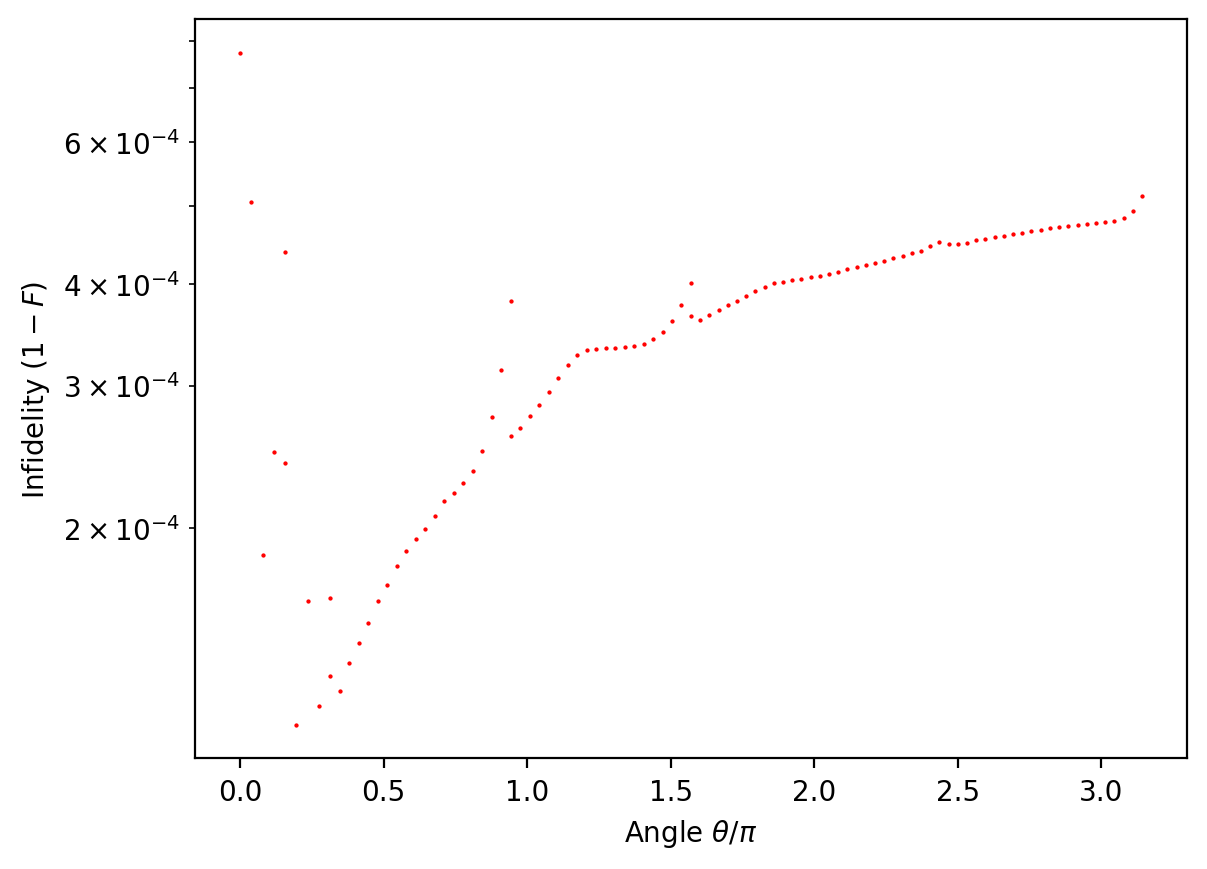

In [47]:
# first we list the filenames of the NNs and the ranges they operate in 
directory_ = "data/final_models/"
filename0 = [directory_+"5e-5pi_to_0.05pi", np.array([5e-5*torch.pi, 0.05*torch.pi])]
filename1 = [directory_+"0.05pi_to_0.1pi", np.array([0.05*torch.pi, 0.1*torch.pi])]
filename2 = [directory_+"pt1pi_to_pt3pi",np.array([0.1*torch.pi, 0.3*torch.pi])]
filename3 = [directory_+"pt3pi_to_pt5pi", np.array([0.3*torch.pi, 0.5*torch.pi])]
filename4 = [directory_+"pt5pi_to_pi", np.array([0.5*torch.pi, torch.pi])]
iter_list = [filename0, filename1, filename2, filename3, filename4]

#"data/fidelity_data/pt1pi_to_pt3pi"
a1 = run_file(iter_list)
for i in iter_list:
    f = torch.load(i[0])["network"]
#    print(f)
#print(np.mean(fid_arr))

0.0003529614210128784


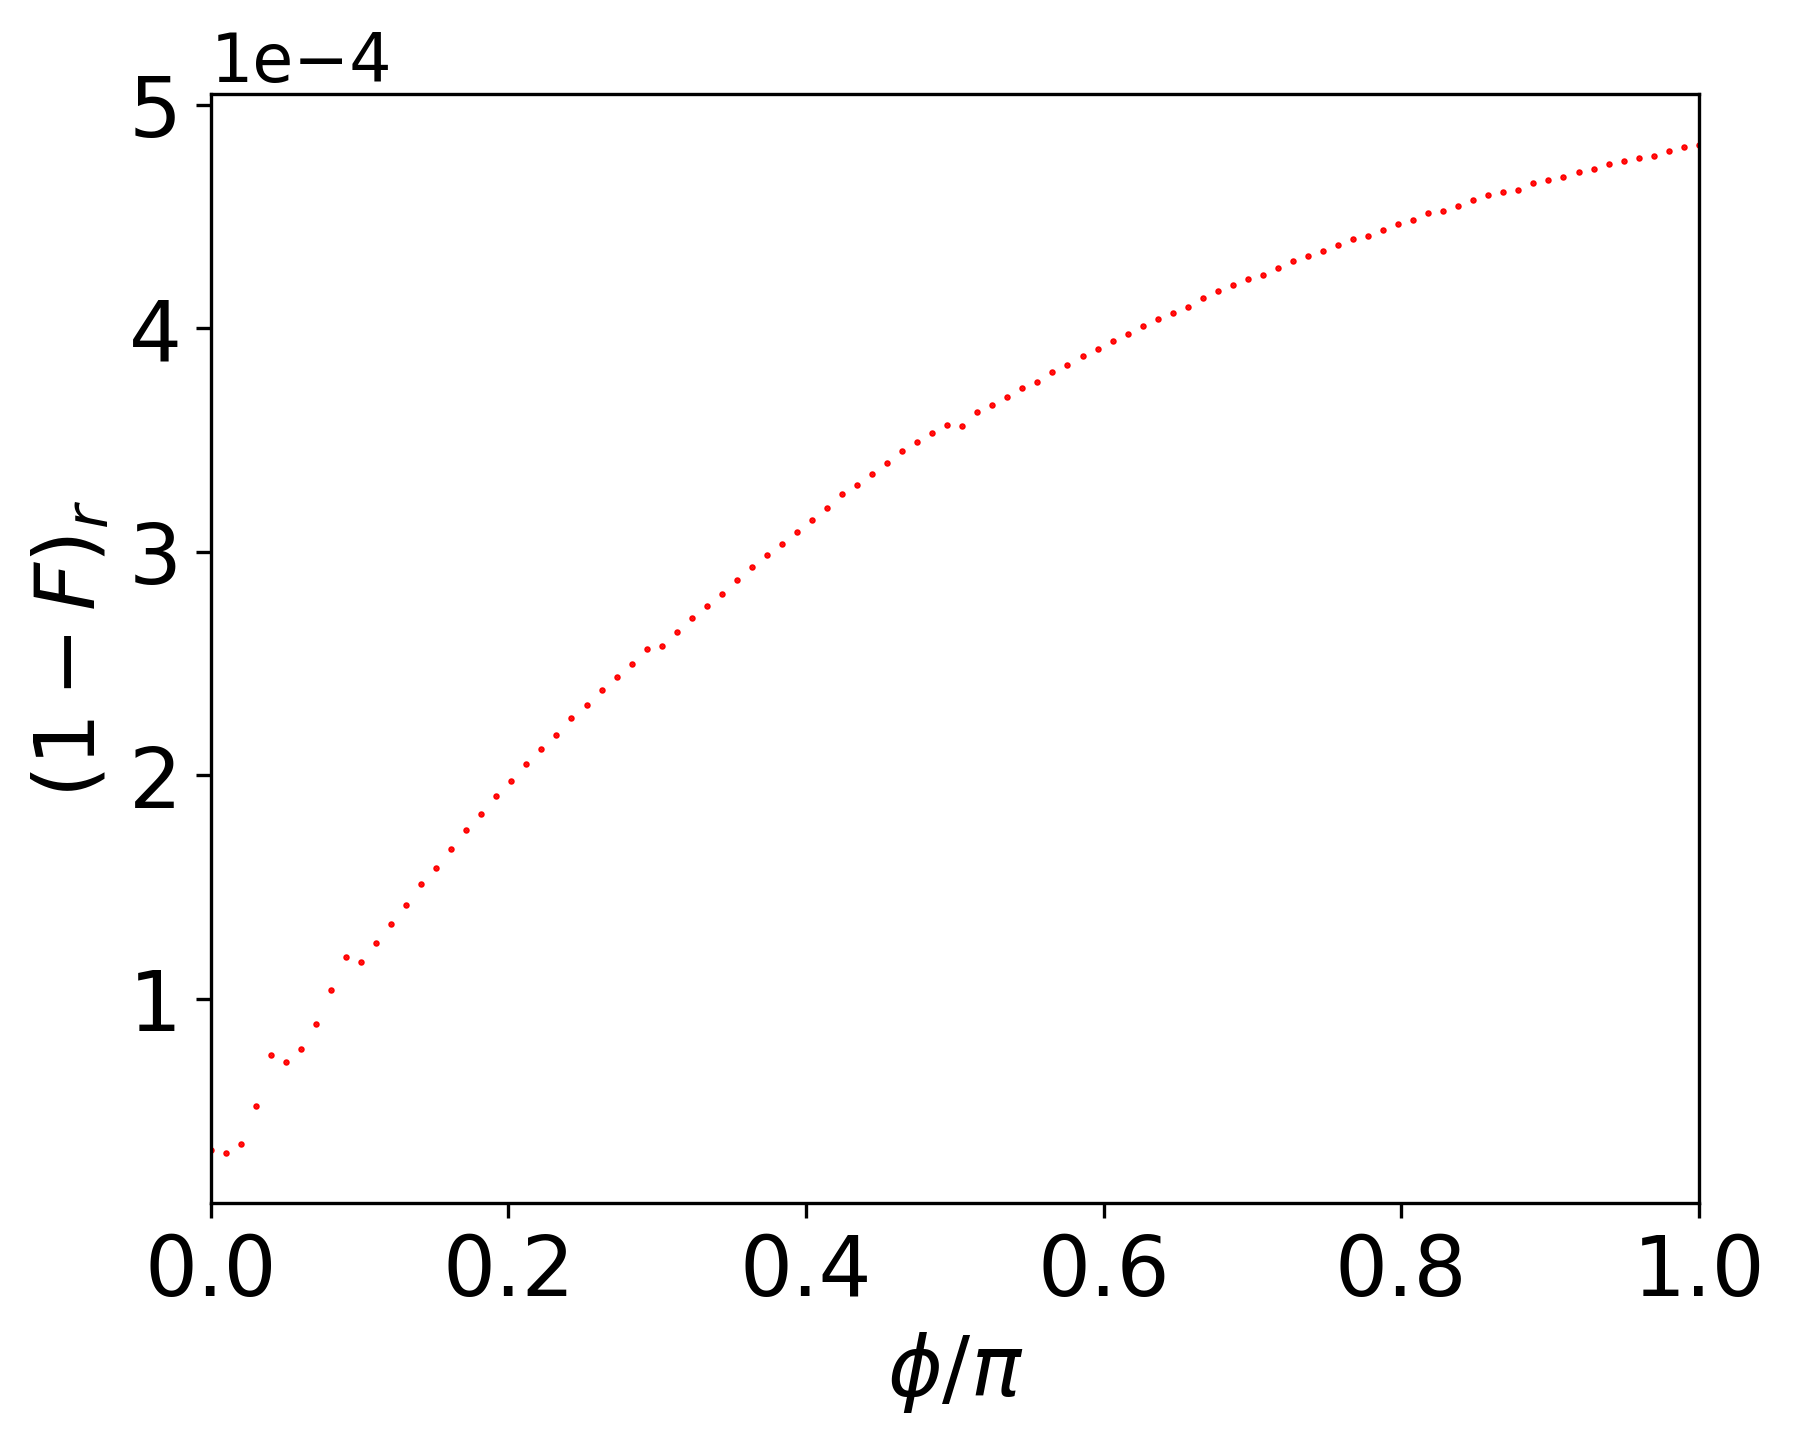

In [62]:
fid_arr = a1[0]
print(np.mean(fid_arr))
plt.figure(dpi = 300)
dec_arr = np.abs(np.array(a1_no_decay[0]) - np.array(a1[0]))[::]
plt.xlim(0,1)

plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.scatter(np.linspace(0, 1, len(dec_arr)), dec_arr, s = 0.3, color = 'red')
plt.xlabel(r"$\phi/\pi$",fontsize = 20)
plt.ylabel(r"$(1-F)_r$",fontsize = 20)
plt.xticks(fontsize=20)  # Change x-axis tick label size
plt.yticks(fontsize=20)  # Change y-axis tick label size
plt.rc('font', size=16)


7.9626418075139656
1.066151407756535 278.859205127291


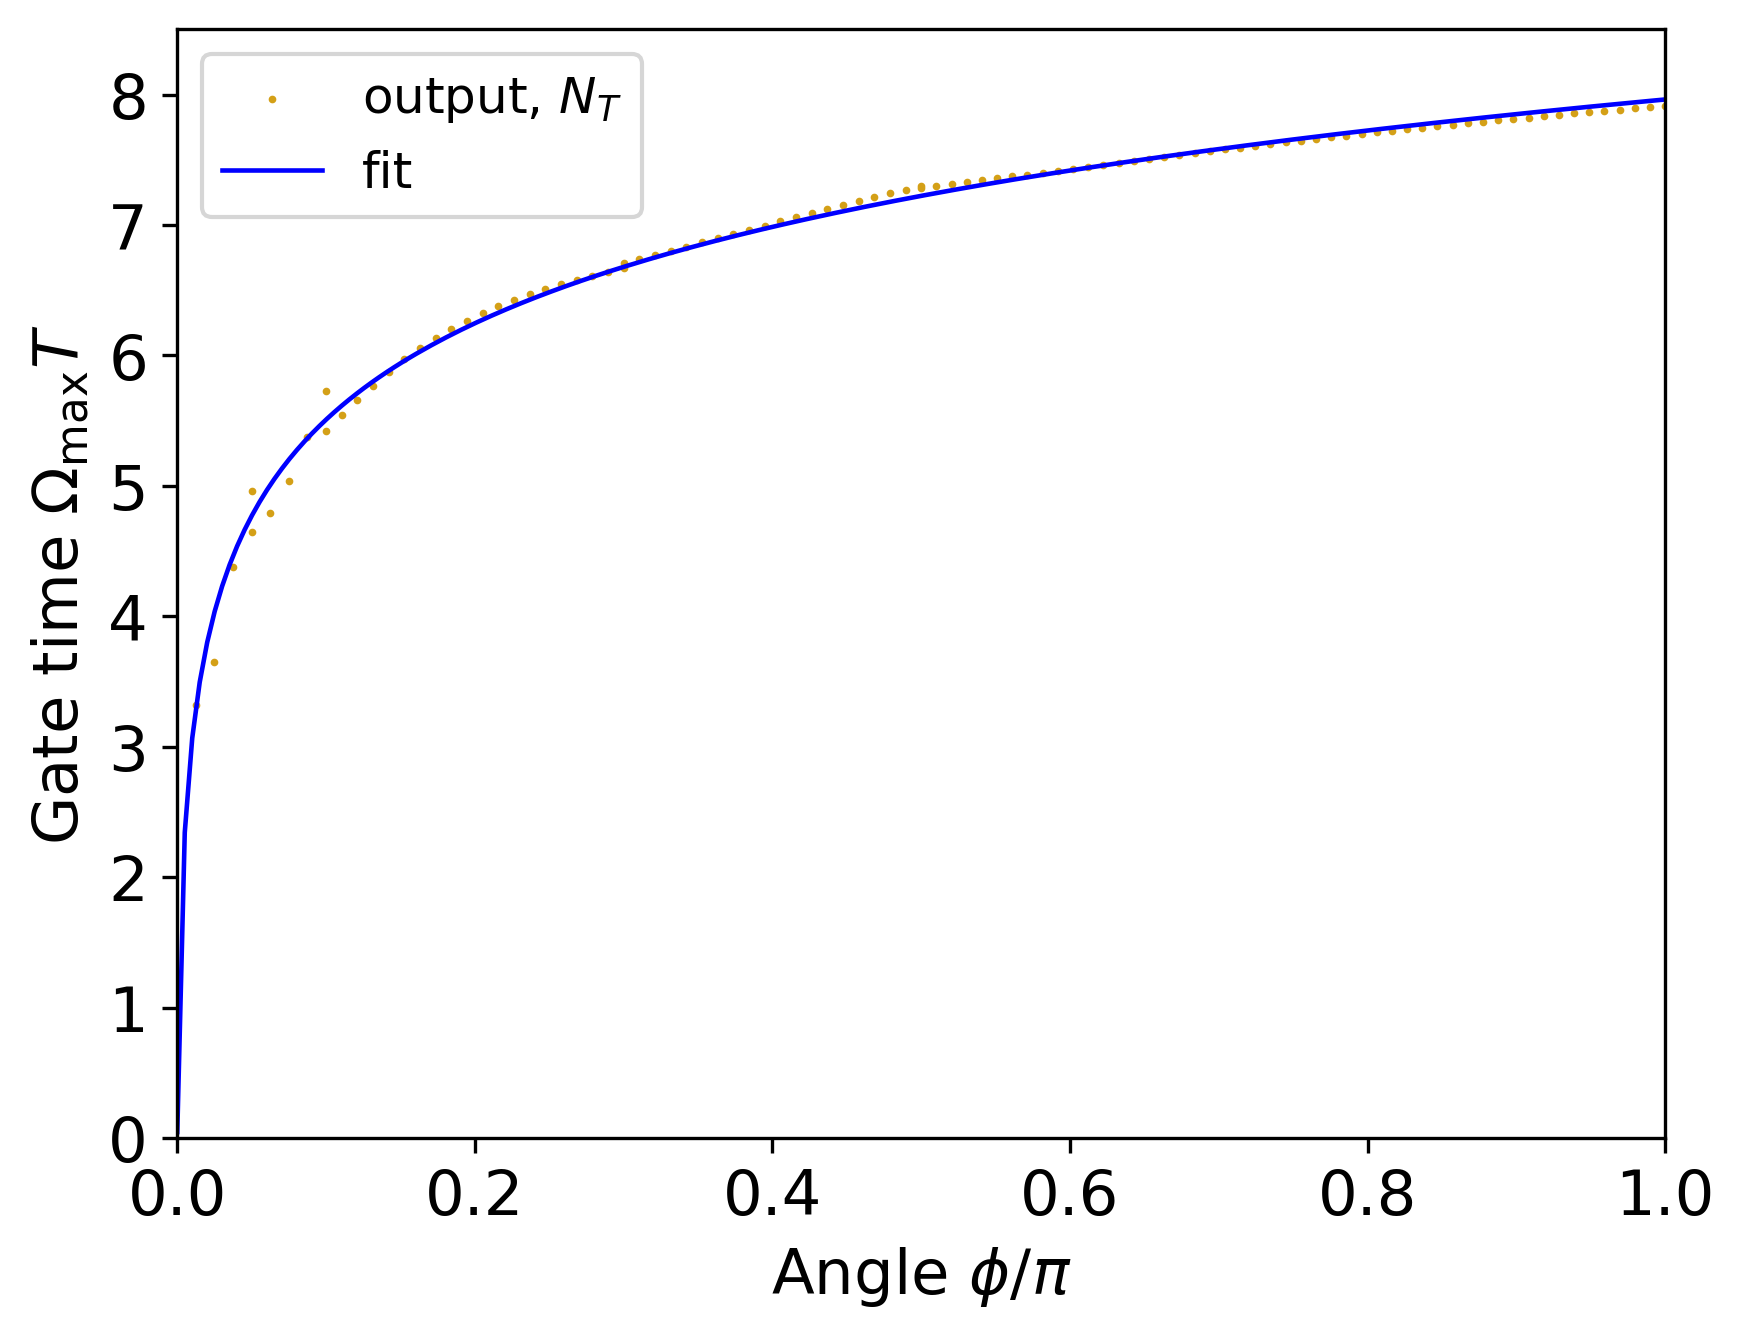

In [42]:
from scipy.interpolate import make_interp_spline
from scipy.optimize import curve_fit

#def model_func(x, a, b, c, d):
#    return a**(-x**b) + d

def model_func(x, a, b):
    return a*np.arcsinh(b*x) 

gatetime_arr = a1[1]*cfn.rabi
x_list = np.array(a1[2]).reshape(100)
#x_list = torch.linspace(0, torch.pi, 200)

params, covariance = curve_fit(model_func, x_list, gatetime_arr)

a, b = params
#print(a, b, c, d)
# Generate points for the fitted curve
x_fit = np.linspace(min(x_list), max(x_list), 200)
y_fit = model_func(x_fit, *params)

#X_Y_Spline = make_interp_spline(x_list, gatetime_arr)
#X_ = np.linspace(x_list.min(), x_list.max(), 600)
#Y_ = X_Y_Spline(X_)

fid_arr = a1[0]
plt.figure(dpi = 300)

plt.ylabel(r'Gate time $\Omega_{\mathrm{max}} T$', fontsize = 15)
plt.xlabel(r'Angle $\phi/\pi$', fontsize = 15)
plt.xlim(0.00/torch.pi, torch.pi/torch.pi)
plt.ylim(0, 8.5)
plt.scatter(x_list[1:]/torch.pi, gatetime_arr[1:], s = 0.7, color = '#d4a017', label = r'output, $N_T$')
#plt.scatter(X_, Y_, s = 0.3)
plt.plot(x_fit[0:]/torch.pi, y_fit[0:], color = 'blue', linewidth = 1.1, label = 'fit')
plt.legend(fontsize = 12)
print(y_fit[-1])
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
print(a, b)
#plt.scatter(X_, Y_, s = 0.3, color = 'red')

In [39]:
#print(x_list)
#print(gatetime_arr)

In [67]:
# save plot data, mainly to piece together the networks for multiple angle cases 
filename = "data/fidelity_data/pt1pi_to_pt3pi"
dict_ = {'infidelity': fidelity_arr, 'angle': angle_list}

torch.save(dict_, filename)

In [66]:
#soln = torch.tensor(soln)
filename = "data/final_models/pt1pi_to_pt3pi"
dict_ = cfn._optim_to_dict(composite_network, \
    'n/a', desired_angle, 'n/a', [nn_solver_1, nn_solver_2], loss_val = 'n/a')

torch.save(dict_, filename)